# **EXOPLANET HABITABILITY CLASSIFICATION PROJECT**

### RIDIMA

This notebook is a ML project, classifying exoplanets on their habitability from various mission data. 

In [120]:
#Import all the essentials libraries

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.impute import IterativeImputer
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler


#Machine Learning Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn import tree
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB


In [2]:
#Open the data
df = pd.read_csv("phl_exoplanet_catalog_2019.csv")
df.head()

,P_NAME,P_STATUS,P_MASS,P_MASS_ERROR_MIN,P_MASS_ERROR_MAX,P_RADIUS,P_RADIUS_ERROR_MIN,P_RADIUS_ERROR_MAX,P_YEAR,P_UPDATED,...,P_HABZONE_CON,P_TYPE_TEMP,P_HABITABLE,P_ESI,S_CONSTELLATION,S_CONSTELLATION_ABR,S_CONSTELLATION_ENG,P_RADIUS_EST,P_MASS_EST,P_SEMI_MAJOR_AXIS_EST
0,11 Com b,3.0,6165.86330,-476.74200,476.74200,NaN,NaN,NaN,2007,2014-05-14,...,0,Hot,0,0.083813,Coma Berenices,Com,Berenice's Hair,12.082709,6165.86330,1.29
1,11 UMi b,3.0,4684.78480,-794.57001,794.57001,NaN,NaN,NaN,2009,2018-09-06,...,0,Hot,0,0.082414,Ursa Minor,UMi,Little Bear,12.229641,4684.78480,1.53
2,14 And b,3.0,1525.57440,NaN,NaN,NaN,NaN,NaN,2008,2014-05-14,...,0,Hot,0,0.081917,Andromeda,And,Andromeda,12.848516,1525.57440,0.83
3,14 Her b,3.0,1481.07850,-47.67420,47.67420,NaN,NaN,NaN,2002,2018-09-06,...,0,Cold,0,0.145241,Hercules,Her,Hercules,12.865261,1481.07850,2.93
4,16 Cyg B b,3.0,565.73385,-25.42624,25.42624,NaN,NaN,NaN,1996,2018-09-06,...,1,Warm,0,0.368627,Cygnus,Cyg,Swan,13.421749,565.73385,1.66


In [150]:
df.columns.to_list()

['P_NAME',
 'P_YEAR',
 'P_UPDATED',
 'P_PERIOD',
 'P_SEMI_MAJOR_AXIS',
 'P_ANGULAR_DISTANCE',
 'P_DETECTION',
 'S_NAME',
 'S_RA',
 'S_DEC',
 'S_DISTANCE',
 'S_MASS',
 'S_MASS_ERROR_MIN',
 'S_MASS_ERROR_MAX',
 'S_RADIUS',
 'S_RADIUS_ERROR_MIN',
 'S_RADIUS_ERROR_MAX',
 'S_AGE_ERROR_MIN',
 'S_AGE_ERROR_MAX',
 'S_TEMPERATURE',
 'S_LOG_G',
 'S_ALT_NAMES',
 'P_FLUX',
 'P_TYPE',
 'S_TYPE_TEMP',
 'S_DEC_T',
 'S_TIDAL_LOCK',
 'P_HABZONE_OPT',
 'P_HABZONE_CON',
 'P_TYPE_TEMP',
 'S_CONSTELLATION',
 'S_CONSTELLATION_ENG',
 'P_RADIUS_EST',
 'P_MASS_EST',
 'P_HABITABLE']

In [4]:
shape = df.shape
print(f'Rows: {shape[0]}')
print(f'Columns: {shape[1]}')

Rows: 4048
Columns: 112


In [5]:
null_vales = df.isnull().sum().sort_values(ascending = False)
null_vales.head(40)

P_ATMOSPHERE                    4048
P_ALT_NAMES                     4048
P_DETECTION_RADIUS              4048
P_GEO_ALBEDO                    4048
P_DETECTION_MASS                4048
S_MAGNETIC_FIELD                4048
S_DISC                          4048
P_TEMP_MEASURED                 4043
P_GEO_ALBEDO_ERROR_MIN          4043
P_GEO_ALBEDO_ERROR_MAX          4043
P_TPERI_ERROR_MAX               3576
P_TPERI_ERROR_MIN               3576
P_TPERI                         3567
P_OMEGA_ERROR_MIN               3355
P_OMEGA_ERROR_MAX               3355
P_ESCAPE                        3342
P_POTENTIAL                     3342
P_DENSITY                       3342
P_GRAVITY                       3342
P_OMEGA                         3302
P_INCLINATION_ERROR_MAX         3238
P_INCLINATION_ERROR_MIN         3236
P_INCLINATION                   3204
P_ECCENTRICITY_ERROR_MIN        3077
P_ECCENTRICITY_ERROR_MAX        3077
S_TYPE                          2678
P_ECCENTRICITY                  2668
P

### **PREPRCESSING**

<Axes: >

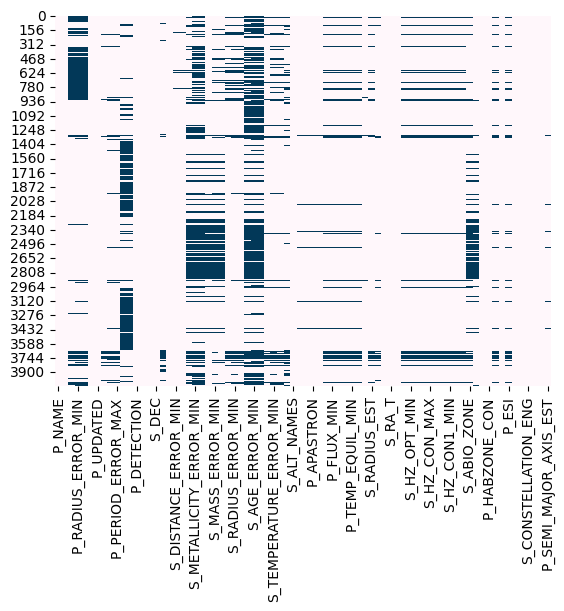

In [ ]:
#Plots a heatmap of the missing values in the dataset
sns.heatmap(df.isnull(), cbar=False, cmap='PuBu') 

In [10]:
df.isnull().sum().sort_values(ascending=False)

S_AGE_ERROR_MAX        2161
S_AGE_ERROR_MIN        2161
S_AGE                  2017
P_ANGULAR_DISTANCE     1687
P_SEMI_MAJOR_AXIS      1681
                       ... 
P_HABITABLE               0
S_CONSTELLATION_ABR       0
S_CONSTELLATION_ENG       0
P_RADIUS_EST              0
P_MASS_EST                0
Length: 76, dtype: int64

In [ ]:
#Dropping all the columns with null  values
df = df.drop(["P_DETECTION_MASS", "P_GEO_ALBEDO", "S_MAGNETIC_FIELD", "S_DISC", "P_ATMOSPHERE", "P_ALT_NAMES", "P_DETECTION_RADIUS", "P_GEO_ALBEDO_ERROR_MIN", "P_TEMP_MEASURED", "P_GEO_ALBEDO_ERROR_MAX","P_TPERI_ERROR_MAX", "P_TPERI_ERROR_MIN", "P_TPERI", "P_OMEGA_ERROR_MIN", "P_OMEGA_ERROR_MAX", "P_DENSITY", "P_ESCAPE", "P_POTENTIAL", "P_GRAVITY", "P_OMEGA",   "P_INCLINATION_ERROR_MAX", "P_INCLINATION_ERROR_MIN", "P_INCLINATION", "P_ECCENTRICITY_ERROR_MAX", "P_ECCENTRICITY_ERROR_MIN", "S_TYPE", "P_ECCENTRICITY","P_IMPACT_PARAMETER_ERROR_MIN", "P_IMPACT_PARAMETER_ERROR_MAX", "P_IMPACT_PARAMETER", "P_MASS_ERROR_MAX", "P_MASS_ERROR_MIN", "P_HILL_SPHERE", "P_SEMI_MAJOR_AXIS_ERROR_MIN", "P_SEMI_MAJOR_AXIS_ERROR_MAX", "P_MASS"], axis=1)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4048 entries, 0 to 4047
Data columns (total 76 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   P_NAME                   4048 non-null   object 
 1   P_STATUS                 4048 non-null   float64
 2   P_RADIUS                 3139 non-null   float64
 3   P_RADIUS_ERROR_MIN       3105 non-null   float64
 4   P_RADIUS_ERROR_MAX       3105 non-null   float64
 5   P_YEAR                   4048 non-null   int64  
 6   P_UPDATED                4048 non-null   object 
 7   P_PERIOD                 3938 non-null   float64
 8   P_PERIOD_ERROR_MIN       3807 non-null   float64
 9   P_PERIOD_ERROR_MAX       3807 non-null   float64
 10  P_SEMI_MAJOR_AXIS        2367 non-null   float64
 11  P_ANGULAR_DISTANCE       2361 non-null   float64
 12  P_DETECTION              4048 non-null   object 
 13  S_NAME                   4048 non-null   object 
 14  S_RA                    

Our data is divided into categorical and numeric datatypes

In [13]:
#Null values in the categorical data columns
df.select_dtypes(include=['object']).isnull().sum().sort_values(ascending=False)

P_TYPE_TEMP            327
S_TYPE_TEMP            136
P_TYPE                  17
P_UPDATED                0
P_NAME                   0
S_ALT_NAMES              0
S_NAME                   0
P_DETECTION              0
S_RA_T                   0
S_DEC_T                  0
S_CONSTELLATION          0
S_CONSTELLATION_ABR      0
S_CONSTELLATION_ENG      0
dtype: int64

In [14]:
print(df['P_TYPE'])
df['P_TYPE'].isnull().sum()

0            Jovian
1            Jovian
2            Jovian
3            Jovian
4            Jovian
           ...     
4043    Superterran
4044      Neptunian
4045         Terran
4046         Terran
4047         Terran
Name: P_TYPE, Length: 4048, dtype: object


np.int64(17)

The “P_TYPE” column in our data describes the exoplanet category and consists of six possible values: Jovian, Superterran, Neptunian, Terran, Subterran, and Miniterran. This feature had 17 missing values.

TO handle the missing values, we can impute them using mode

In [80]:
df['P_TYPE'] = df['P_TYPE'].fillna(df['P_TYPE'].mode()[0]) #set the first most common value
df['P_TYPE_TEMP'] = df['P_TYPE_TEMP'].fillna(df['P_TYPE_TEMP'].mode()[0])
df['S_TYPE_TEMP'] = df['S_TYPE_TEMP'].fillna(df['S_TYPE_TEMP'].mode()[0]) 

In [81]:
#Converting sll the categorical data into integer data
lencoders = {}
for col in df.select_dtypes(include=['object']).columns:
    lencoders[col] = LabelEncoder()
    df[col] = lencoders[col].fit_transform(df[col])

nOw WE HANDLED MISSING VALUES IN CATEGORICAL DATA and encoded them, NO WE WILL WORK UPON NUMERICAL DATA 

We are going to use Scikit-learn's imputer because it provides a systematic way to replace missing numerical data, and IterativeImputer is particularly useful when we want to use relationships between multiple features to make those replacements.


In [82]:
imp = IterativeImputer(max_iter=10, verbose=0) #Creates an iterative imputer object
imp.fit(df) #Fits the imputer to the dataframe
imputed_df = imp.transform(df) #Transforms the data
df = pd.DataFrame(imputed_df, columns=df.columns) #Creates a dataframe from the imputed data. 

In [83]:
# Checking for missing values
df.isnull().sum().sort_values(ascending=False)

P_NAME                 0
P_YEAR                 0
P_UPDATED              0
P_PERIOD               0
P_SEMI_MAJOR_AXIS      0
P_ANGULAR_DISTANCE     0
P_DETECTION            0
S_NAME                 0
S_RA                   0
S_DEC                  0
S_DISTANCE             0
S_MASS                 0
S_MASS_ERROR_MIN       0
S_MASS_ERROR_MAX       0
S_RADIUS               0
S_RADIUS_ERROR_MIN     0
S_RADIUS_ERROR_MAX     0
S_AGE_ERROR_MIN        0
S_AGE_ERROR_MAX        0
S_TEMPERATURE          0
S_LOG_G                0
S_ALT_NAMES            0
P_FLUX                 0
P_TYPE                 0
S_TYPE_TEMP            0
S_DEC_T                0
S_TIDAL_LOCK           0
P_HABZONE_OPT          0
P_HABZONE_CON          0
P_TYPE_TEMP            0
S_CONSTELLATION        0
S_CONSTELLATION_ENG    0
P_RADIUS_EST           0
P_MASS_EST             0
P_HABITABLE            0
dtype: int64

we have corrected all of our missing values! But, we still have a major class imbalance to work with. Since we don’t know of many potentially habitable planets, the number of inhabitable exoplanets greatly outnumbers the habitable ones. This will likely cause our model to guess an exoplanet is inhabitable, even if it’s not the case, because it will still have an average of like 99% accuracy. Thus, we need to find a way to balance the scales.

We will use upsampling method, using algorithm SMOTE.

In [84]:
# Checking if imbalance is fixed
df['P_HABITABLE'].value_counts()

P_HABITABLE
2.0    3002
1.0    3002
0.0    3002
Name: count, dtype: int64

In [21]:
df.shape

(11979, 76)

After balancing the data, we can now move to visualize the data

First we will visualise it using a correlation heatmap as the model might learn correlations that aren’t really related to the actual habitability of the planet.

<Axes: >

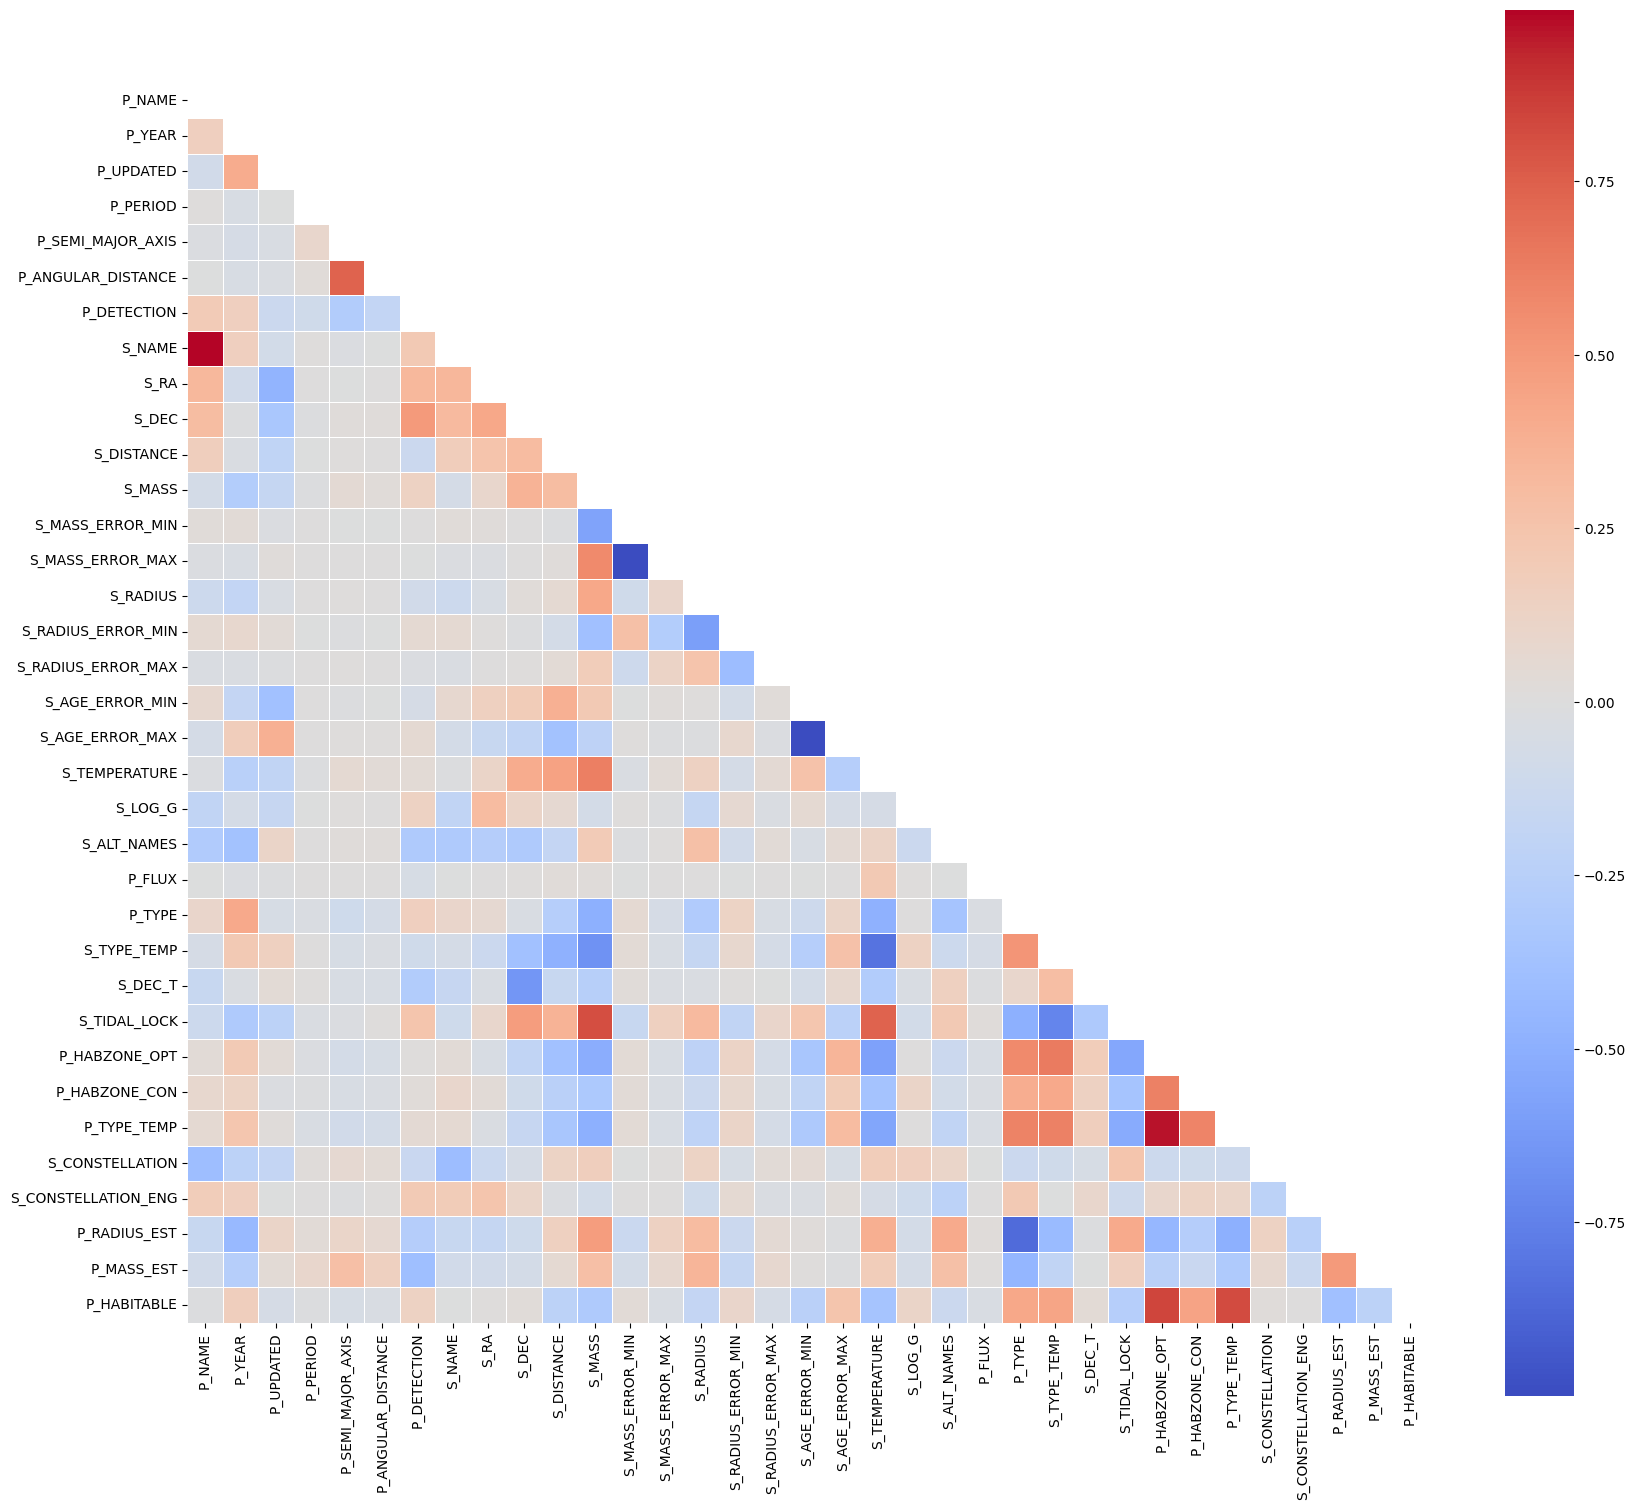

In [85]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=np.bool))
f,ax = plt.subplots(figsize=(20,20))

sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, square=True,annot=False, linewidths=.5, cbar_kws={"shrink": 0.9})

The dark red squares indicate that the two corresponding variables are highly related to one another and might cause unwanted connections in our machine learning model.

In [ ]:
#Dropping one of each which are highly corelated to each other
working_data = df.drop([ 'P_RADIUS', 'P_RADIUS_ERROR_MIN', 'P_RADIUS_ERROR_MAX', 'P_DISTANCE', 'P_PERIASTRON', 'P_APASTRON', 'P_DISTANCE_EFF', 'P_FLUX_MIN', 'P_FLUX_MAX', 'P_TEMP_EQUIL', 'P_TEMP_EQUIL_MIN', 'P_TEMP_EQUIL_MAX', 'S_RADIUS_EST', 'S_RA_H', 'S_RA_T', 'S_LUMINOSITY', 'S_HZ_OPT_MIN', 'S_HZ_OPT_MAX', 'S_HZ_CON_MIN', 'S_HZ_CON_MAX', 'S_HZ_CON0_MIN', 'S_HZ_CON0_MAX', 'S_HZ_CON1_MIN', 'S_HZ_CON1_MAX', 'S_SNOW_LINE', 'P_PERIOD_ERROR_MIN',  'P_PERIOD_ERROR_MAX', 'S_MAG', 'S_DISTANCE_ERROR_MIN', 'S_DISTANCE_ERROR_MAX', 'S_METALLICITY', 'S_METALLICITY_ERROR_MIN', 'S_METALLICITY_ERROR_MAX', 'S_AGE', 'S_TEMPERATURE_ERROR_MIN', 'S_TEMPERATURE_ERROR_MAX', 'S_ABIO_ZONE', 'P_ESI', 'S_CONSTELLATION_ABR', 'P_SEMI_MAJOR_AXIS_EST'], axis=1)

<Axes: >

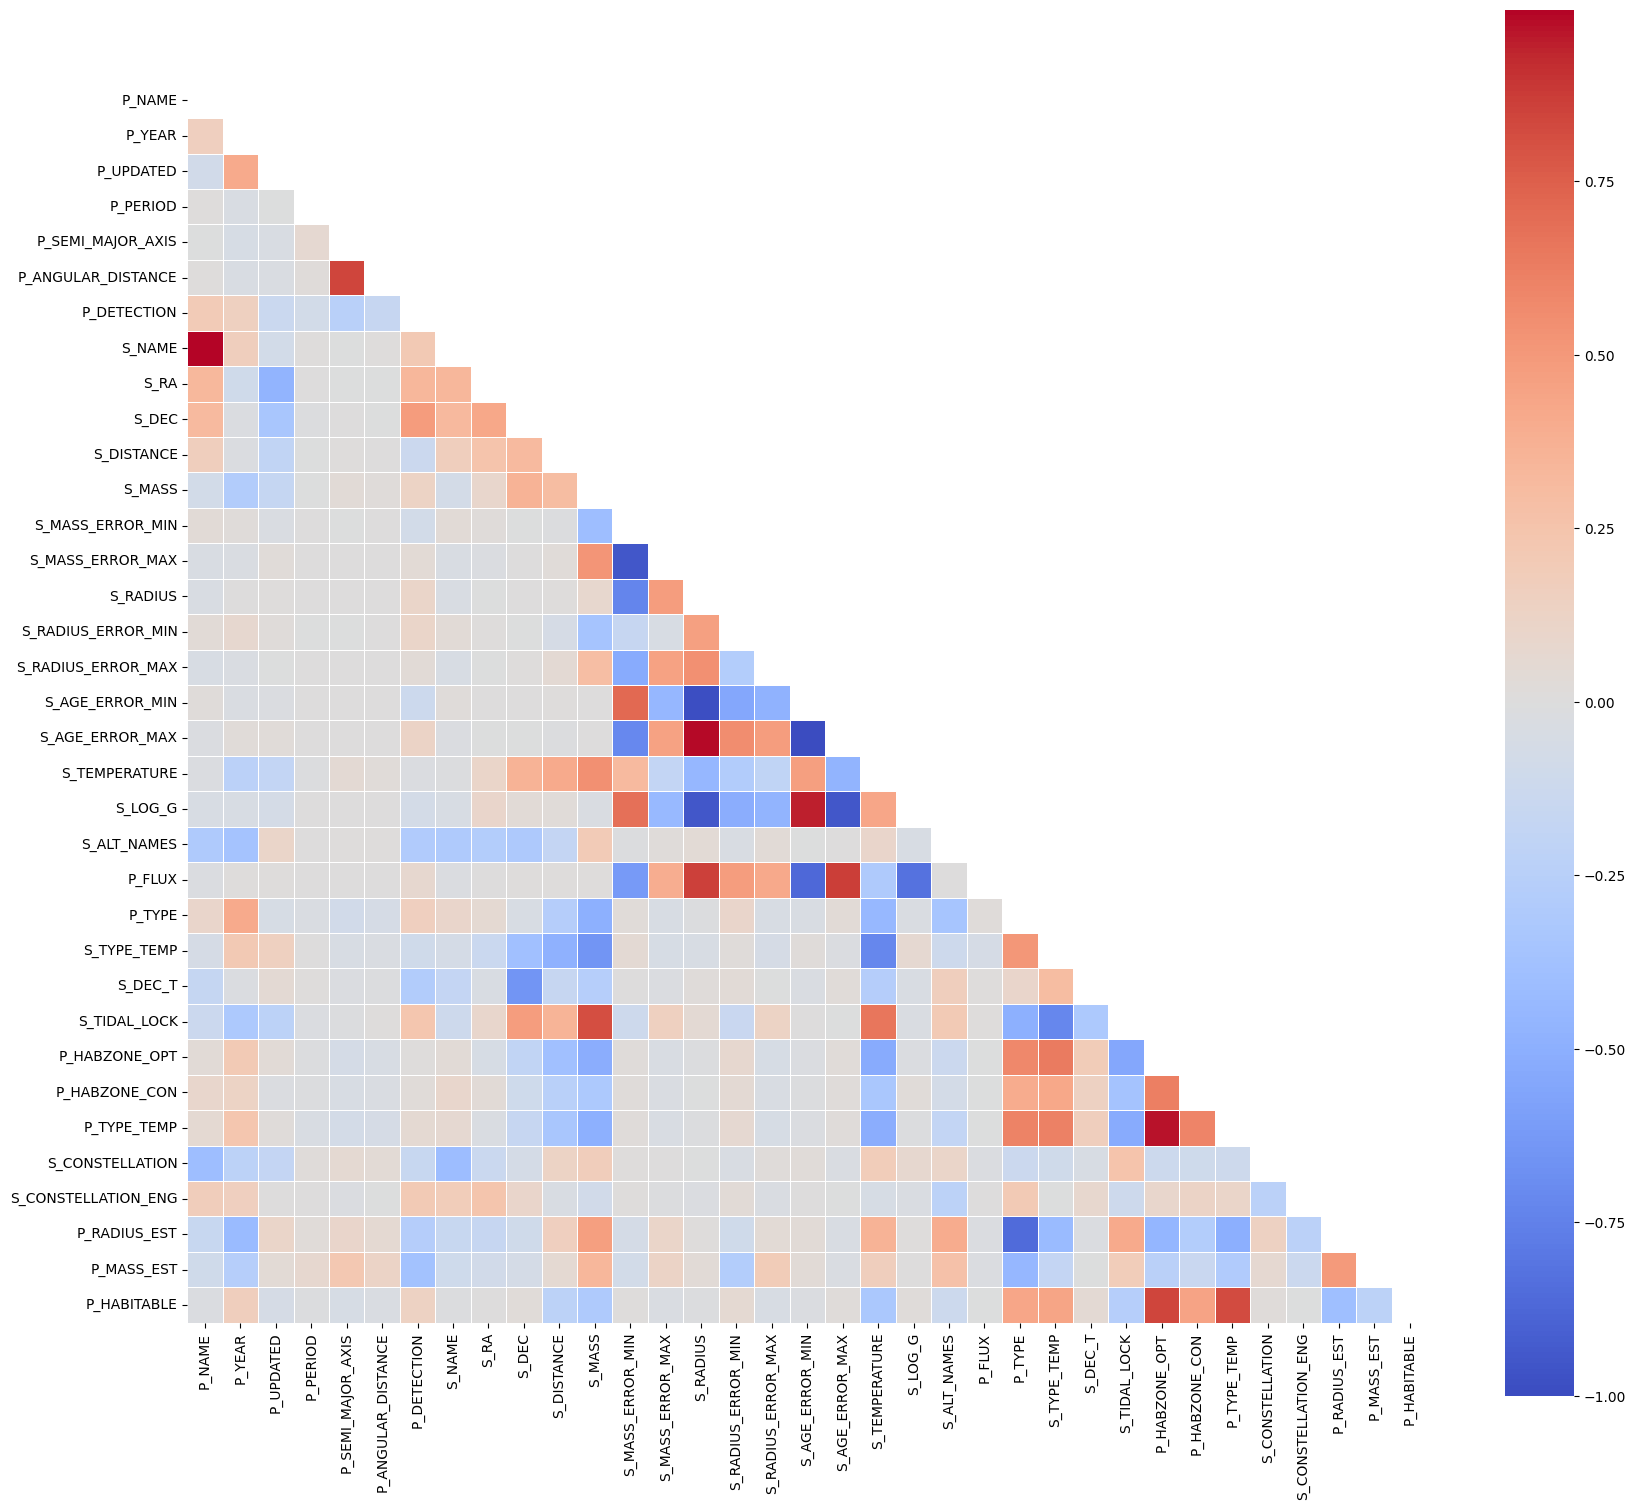

In [88]:
corr = working_data.corr()
mask = np.triu(np.ones_like(corr, dtype=np.bool))
f,ax = plt.subplots(figsize=(20,20))

sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, square=True,annot=False, linewidths=.5, cbar_kws={"shrink": 0.9})

In [ ]:
working_data["P_STATUS"].value_counts()

In [30]:
#Since ther's only one value we can drop it 
working_data = working_data.drop('P_STATUS', axis = 1)

## **Splitting into Train/Test**

In [90]:
X = working_data.loc[:, working_data.columns != "P_HABITABLE"]
y = working_data["P_HABITABLE"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42)
print("Training/testing: ", len(X_train), '/', len(X_test))


Training/testing:  8984 / 2995


In [91]:
X= df.iloc[:, df.columns != 'P_HABITABLE']
y = df['P_HABITABLE']
smote = SMOTE(sampling_strategy='auto', k_neighbors=5, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

df = pd.concat([pd.DataFrame(X_train_smote), pd.DataFrame(y_train_smote)], axis = 1 )
df.head()

,P_NAME,P_YEAR,P_UPDATED,P_PERIOD,P_SEMI_MAJOR_AXIS,P_ANGULAR_DISTANCE,P_DETECTION,S_NAME,S_RA,S_DEC,...,S_DEC_T,S_TIDAL_LOCK,P_HABZONE_OPT,P_HABZONE_CON,P_TYPE_TEMP,S_CONSTELLATION,S_CONSTELLATION_ENG,P_RADIUS_EST,P_MASS_EST,P_HABITABLE
0,1943.685591,2016.000000,66.000000,239.005812,6.627737,193.130701,8.0,1544.544520,295.542897,47.184186,...,1709.259253,0.446820,1.0,0.000000,2.0,30.000000,75.000000,1.999821,4.679221,2.0
1,2154.681678,2016.642087,99.388498,150.473969,2.674323,69.524104,8.0,1721.050381,296.753837,44.110159,...,1255.873901,0.426818,1.0,1.000000,2.0,30.000000,75.000000,2.034313,4.818633,2.0
2,1674.116628,2016.883295,105.748292,83.889556,3.773043,108.939093,8.0,1322.013667,182.692524,31.073506,...,587.377524,0.319794,1.0,1.000000,2.0,62.482840,31.334093,2.231175,5.664351,2.0
3,1849.267423,2015.359394,51.586375,100.638879,4.643225,132.074360,8.0,1453.870180,297.860169,46.022451,...,1552.418600,0.364029,1.0,1.000000,2.0,30.000000,75.000000,1.325848,2.269959,1.0
4,171.851341,2014.170999,35.715473,32.714900,0.132385,18.430687,7.0,131.949838,219.590293,-36.854007,...,2794.100324,0.270956,1.0,0.804833,2.0,65.754671,61.633834,1.356890,2.387930,1.0


In [92]:
y_train_smote.value_counts("P_HABITABLE")

P_HABITABLE
2.0    0.333333
1.0    0.333333
0.0    0.333333
Name: proportion, dtype: float64

## **FEATURE SELECTION**

In [171]:
feat_labels = df.columns[1:]

forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X_train_smote, y_train_smote)

importance = forest.feature_importances_

index = np.argsort(importance)[::-1]

for i in range(X_train_smote.shape[1]):
    print(feat_labels[index[i]], "               " ,importance[index[i]])


P_HABZONE_CON                 0.13866545048794998
S_TYPE_TEMP                 0.13677991010400617
P_TYPE                 0.12374098221713842
S_CONSTELLATION                 0.09746156833636727
P_MASS_EST                 0.09211032282313658
P_HABITABLE                 0.0857011102157068
S_LOG_G                 0.03598375338403549
P_HABZONE_OPT                 0.03506594234196687
S_MASS_ERROR_MIN                 0.034943989888175736
P_SEMI_MAJOR_AXIS                 0.03299269754564584
P_TYPE_TEMP                 0.03228117186963238
S_DEC_T                 0.022980149686103866
S_RADIUS                 0.01633179767178304
S_RADIUS_ERROR_MIN                 0.014137889600258502
P_ANGULAR_DISTANCE                 0.0138347621119037
S_MASS                 0.013624868380915449
S_ALT_NAMES                 0.010499051538627409
S_MASS_ERROR_MAX                 0.009060920722262437
S_CONSTELLATION_ENG                 0.0078758846321573
S_NAME                 0.006709845697063158
S_AGE_ERROR_MIN  

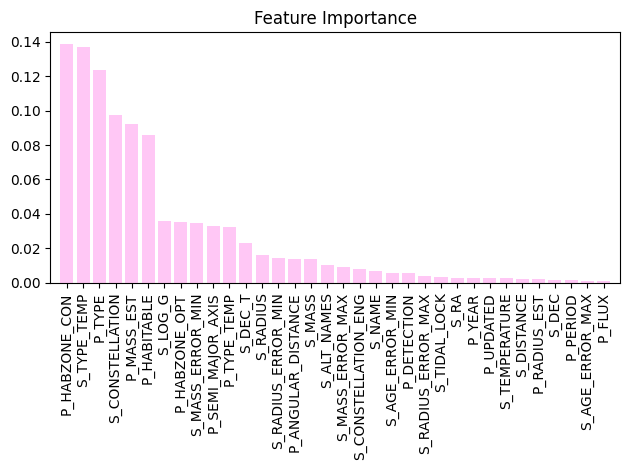

In [173]:
plt.title("Feature Importance")
plt.bar(range(X_train_smote.shape[1]),
        importance[index],
        align = 'center', 
        color= "#ffc7f5")


plt.xticks(range(X_train_smote.shape[1]),
        feat_labels[index], rotation=90)

plt.xlim([-1, X_train_smote.shape[1]])
plt.tight_layout()

plt.savefig("Feature-importance.png")
plt.show()

In [95]:
#We removed all those features which have importance less then 1%
sfm = SelectFromModel(forest,threshold=0.01, prefit=True)
#Created a new data frame for training and testing after removing those features which had importance < 1%
X_selected_train = pd.DataFrame(sfm.transform(X_train_smote))
X_selected_test = pd.DataFrame(sfm.transform(X_test))

A = pd.DataFrame(X_selected_train)
B= pd.DataFrame(X_selected_test)

features = X_train_smote.loc[:, sfm.get_support()].columns
A.columns = features
B.columns = A.columns

print('Number of training features that meet this threshold criterion:',  X_selected_train.shape[1])
print('Number of test features that meet the threshold criteria: ', X_selected_test.shape[1])

Number of training features that meet this threshold criterion: 17
Number of test features that meet the threshold criteria:  17


c:\Users\MSII\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
c:\Users\MSII\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In A we got all the features whose feature importance was > 1% for training purpose. 

In B we got all the features whose feature importance was > 1% for testnig purpose. 

In [96]:
A.head()

,P_PERIOD,P_SEMI_MAJOR_AXIS,S_DISTANCE,S_MASS,S_MASS_ERROR_MAX,S_RADIUS,S_TEMPERATURE,S_LOG_G,P_FLUX,P_TYPE,S_TYPE_TEMP,S_TIDAL_LOCK,P_HABZONE_OPT,P_HABZONE_CON,P_TYPE_TEMP,P_RADIUS_EST,P_MASS_EST
0,239.005812,6.627737,819.672784,0.933130,0.050000,0.906426,5579.614198,4.496815,1.324365,4.0,3.000000,0.446820,1.0,0.000000,2.0,1.999821,4.679221
1,150.473969,2.674323,609.687122,0.752212,0.032842,0.707896,4835.275166,4.616421,0.982801,4.0,4.000000,0.426818,1.0,1.000000,2.0,2.034313,4.818633
2,83.889556,3.773043,175.313392,0.558924,0.025584,0.526590,4010.464426,4.775744,0.702329,4.0,4.441648,0.319794,1.0,1.000000,2.0,2.231175,5.664351
3,100.638879,4.643225,215.500622,0.540000,0.026797,0.513203,3774.711219,4.746797,0.415429,5.0,5.000000,0.364029,1.0,1.000000,2.0,1.325848,2.269959
4,32.714900,0.132385,6.193032,0.289015,0.018048,1.389004,3272.518893,4.616618,0.952228,5.0,5.000000,0.270956,1.0,0.804833,2.0,1.356890,2.387930


In [97]:
B.head()

,P_PERIOD,P_SEMI_MAJOR_AXIS,S_DISTANCE,S_MASS,S_MASS_ERROR_MAX,S_RADIUS,S_TEMPERATURE,S_LOG_G,P_FLUX,P_TYPE,S_TYPE_TEMP,S_TIDAL_LOCK,P_HABZONE_OPT,P_HABZONE_CON,P_TYPE_TEMP,P_RADIUS_EST,P_MASS_EST
0,36.069001,0.147579,6.800000,0.330000,0.020000,1.687998,3350.000000,4.690000,0.984301,5.0,5.000000,0.277482,1.0,0.728367,2.0,1.502784,2.887955
1,70.868459,4.528362,254.287601,0.543150,0.026575,0.526438,3857.449173,4.736850,1.047959,4.0,4.671240,0.345570,1.0,0.671240,2.0,2.041143,4.827754
2,162.094506,2.864301,803.596052,0.789978,0.040000,0.756091,5046.092574,4.585011,1.174970,4.0,3.611232,0.446424,1.0,0.611232,2.0,2.135517,5.207778
3,2309.336719,1.800000,6000.000000,0.370000,0.360000,0.991178,5490.154056,4.449290,158.886886,0.0,3.000000,0.331196,0.0,0.000000,1.0,13.353106,635.656010
4,19.488876,0.076014,4.406596,0.168387,0.012304,0.508998,3044.475415,4.400638,1.147263,5.0,5.000000,0.251749,1.0,0.230417,2.0,1.229452,1.932634


# **TRAINING**

without hyperparameter tuning

In [98]:
models = {
    "Logistic Regression": LogisticRegression(random_state=0, max_iter=10),
    "Decision Tree": tree.DecisionTreeClassifier(max_depth = 5),
    "Random Forest": RandomForestClassifier(n_estimators=5),
    "Support Vector": SVC(),
    "KNN": KNeighborsClassifier(),
    "SGD": SGDClassifier(),
    "Naive Bayes": GaussianNB()
  }


for name, model in models.items():
    model.fit(A, y_train_smote)
    scores = cross_val_score(SGDClassifier(), A, y_train_smote, cv=5)
    print(name + " trained")
    print("Accuracy: %0.2f (+/- %0.2f)" % (scores.mean(), scores.std() * 2))

c:\Users\MSII\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression trained
Accuracy: 0.40 (+/- 0.36)
Decision Tree trained
Accuracy: 0.46 (+/- 0.23)
Random Forest trained
Accuracy: 0.38 (+/- 0.40)
Support Vector trained
Accuracy: 0.39 (+/- 0.26)
KNN trained
Accuracy: 0.48 (+/- 0.26)
SGD trained
Accuracy: 0.42 (+/- 0.38)
Naive Bayes trained
Accuracy: 0.44 (+/- 0.36)


Before the hyperparameter tuning we got; 

- **Logistic Regression:** Accuracy: **0.40 ± 0.35**
- **Decision Tree:** Accuracy: **0.40 ± 0.24**
- **Random Forest:** Accuracy: **0.44 ± 0.35**
- **Support Vector Machine:** Accuracy: **0.46 ± 0.35**
- **K-Nearest Neighbors (KNN):** Accuracy: **0.47 ± 0.24**
- **Stochastic Gradient Descent (SGD):** Accuracy: **0.47 ± 0.31**
- **Naive Bayes:** Accuracy: **0.43 ± 0.38**


While training model, multiple times, by trial and error it came to notice that features like 'P_HABZONE_OPT', 'P_HABZONE_CON', 'P_TYPE_TEMP' were causing data leakage. Due to which models were getting overfitted.


It also came to notice that only features like 'P_PERIOD', 'P_SEMI_MAJOR_AXIS', 'S_DISTANCE', etc were important for classification purpose

In [114]:
features_to_drop = ['P_HABZONE_OPT', 'P_HABZONE_CON', 'P_TYPE_TEMP']
A_clean = A.drop(features_to_drop, axis=1)
B_clean = B.drop(features_to_drop, axis=1)

raw_features = ['P_PERIOD', 'P_SEMI_MAJOR_AXIS', 'S_DISTANCE', 
                'S_MASS', 'S_RADIUS', 'S_TEMPERATURE', 'S_LOG_G']

A_raw = A_clean[raw_features]
B_raw = B_clean[raw_features]

# **TRAINNIG ALL THE MODELS**

Performing hyper parameter tunning 

In [ ]:
#Decision Tree Classifier
dt_grid = GridSearchCV(tree.DecisionTreeClassifier(random_state=0), 
                    {'max_depth': [5, 7, 10], 
                        'min_samples_split': [20, 30],
                        'min_samples_leaf': [8, 10]},
                    cv=5, n_jobs=-1)
dt_grid.fit(A_raw, y_train_smote)
print(f"Decision Tree Test: {dt_grid.score(B_raw, y_test):.3f}")

#Random Forest
rf_grid = GridSearchCV(RandomForestClassifier(n_estimators=100, random_state=0),
                    {'max_depth': [8, 10, 12], 'min_samples_split': [20, 30]},
                    cv=5, n_jobs=-1)
rf_grid.fit(A_raw, y_train_smote)

print(f"Random Forest Test: {rf_grid.score(B_raw, y_test):.3f}")

# KNN
knn_grid = GridSearchCV(KNeighborsClassifier(),
                        {'n_neighbors': [3, 5, 7, 9], 'metric': ['euclidean', 'manhattan']},
                        cv=5, n_jobs=-1)
knn_grid.fit(A_raw, y_train_smote)
print(f"KNN Test: {knn_grid.score(B_raw, y_test):.3f}")

Decision Tree Test: 0.958
Random Forest Test: 0.983
KNN Test: 0.974


In [119]:
#Scaling the training set
scaler = StandardScaler()
A_raw_scaled = scaler.fit_transform(A_raw)
B_raw_scaled = scaler.transform(B_raw)

print("="*60)
print("TUNING REMAINING MODELS (Raw Features Only)")
print("="*60)

# Logistic Regression 
lr_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs'],
    'max_iter': [500, 1000, 2000]
}
lr_grid = RandomizedSearchCV(LogisticRegression(random_state=0), lr_params, cv=5, n_iter=12, n_jobs=-1, random_state=0)
lr_grid.fit(A_raw_scaled, y_train_smote)


# SVM
svm_params = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'poly', 'linear'],
    'gamma': ['scale', 'auto']
}
svm_grid = RandomizedSearchCV(SVC(random_state=0),svm_params, cv=5, n_iter=12, n_jobs=-1, random_state=0)
svm_grid.fit(A_raw_scaled, y_train_smote)


#SGD
sgd_params = {
    'loss': ['log_loss', 'hinge', 'modified_huber'],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'max_iter': [1000, 2000, 5000]
}
sgd_grid = RandomizedSearchCV(SGDClassifier(random_state=0), sgd_params, cv=5, n_iter=15, n_jobs=-1, random_state=0)
sgd_grid.fit(A_raw_scaled, y_train_smote)


# Naive Bayes 
nb_params = {
    'var_smoothing': [1e-12, 1e-9, 1e-8, 1e-7, 1e-6]
}
nb_grid = GridSearchCV(GaussianNB(), nb_params, cv=5, n_jobs=-1)
nb_grid.fit(A_raw, y_train_smote)


TUNING REMAINING MODELS (Raw Features Only)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GaussianNB()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'var_smoothing': [1e-12, 1e-09, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter inde

# **MODEL COMPARISON**

In [166]:

print("COMPREHENSIVE MODEL EVALUATION (Test Set)")

# Dictionary of all models

models = {
    'Decision Tree': (dt_grid.best_estimator_, B_raw),
    'Random Forest': (rf_grid.best_estimator_, B_raw),
    'KNN': (knn_grid.best_estimator_, B_raw_scaled),
    'Logistic Regression': (lr_grid.best_estimator_, B_raw_scaled),
    'SVM': (svm_grid.best_estimator_, B_raw_scaled),
    'SGD': (sgd_grid.best_estimator_, B_raw_scaled),
    'Naive Bayes': (nb_grid.best_estimator_, B_raw)
}

results = []
    

for name, (model, X_eval) in models.items():

    y_pred = model.predict(X_eval)
    accuracy = accuracy_score(y_test, y_pred)
    precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    precision_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    recall_weighted = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results.append({
        'Model': name,
        'Accuracy ': accuracy,
        'Precision ': precision_macro,
        'Recall ': recall_macro,
        'F1 ': f1_macro,
        'F1 (Weighted)': f1_weighted
    })



    print(f"\n{name}")
    print("-" * 70)
    print(f"  Accuracy:          {accuracy:.4f}")
    print(f"  Precision: {precision_macro:.4f}")
    print(f"  Recall:    {recall_macro:.4f}")
    print(f"  F1-Score:  {f1_macro:.4f}")
    print(f"  F1-Score : {f1_weighted:.4f}")


COMPREHENSIVE MODEL EVALUATION (Test Set)

Decision Tree
----------------------------------------------------------------------
  Accuracy:          0.9579
  Precision: 0.9600
  Recall:    0.9580
  F1-Score:  0.9582
  F1-Score : 0.9583

Random Forest
----------------------------------------------------------------------
  Accuracy:          0.9826
  Precision: 0.9829
  Recall:    0.9827
  F1-Score:  0.9827
  F1-Score : 0.9827

KNN
----------------------------------------------------------------------
  Accuracy:          0.3352
  Precision: 0.1117
  Recall:    0.3333
  F1-Score:  0.1674
  F1-Score : 0.1683

Logistic Regression
----------------------------------------------------------------------
  Accuracy:          0.7389
  Precision: 0.7359
  Recall:    0.7384
  F1-Score:  0.7368
  F1-Score : 0.7373


c:\Users\MSII\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(



SVM
----------------------------------------------------------------------
  Accuracy:          0.8100
  Precision: 0.8396
  Recall:    0.8104
  F1-Score:  0.8144
  F1-Score : 0.8145

SGD
----------------------------------------------------------------------
  Accuracy:          0.7299
  Precision: 0.7212
  Recall:    0.7291
  F1-Score:  0.7214
  F1-Score : 0.7219

Naive Bayes
----------------------------------------------------------------------
  Accuracy:          0.6100
  Precision: 0.7334
  Recall:    0.6109
  F1-Score:  0.5888
  F1-Score : 0.5887


In [169]:
# Create DataFrame from results
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by='F1 (Weighted)',
    ascending=False)

print("\nFINAL RANKING")
results_df



FINAL RANKING


,Model,Accuracy,Precision,Recall,F1,F1 (Weighted)
1,Random Forest,0.982638,0.982922,0.982683,0.982661,0.982680
0,Decision Tree,0.957930,0.959965,0.958008,0.958190,0.958257
4,SVM,0.810017,0.839604,0.810359,0.814387,0.814542
3,Logistic Regression,0.738898,0.735857,0.738374,0.736819,0.737267
5,SGD,0.729883,0.721203,0.729053,0.721355,0.721929
6,Naive Bayes,0.610017,0.733361,0.610876,0.588815,0.588667
2,KNN,0.335225,0.111742,0.333333,0.167375,0.168325


In [ ]:

# Detailed report for best model
best_model_name = results_df.iloc[0]['Model']
best_model, best_X = models[best_model_name]
y_pred_best = best_model.predict(best_X)

print(f"\n BEST MODEL: {best_model_name}")
print("-"*70)
print(classification_report(y_test, y_pred_best, target_names=['Habitable' , 'Potentially Habitable ', 'Not-Habitable']))



 BEST MODEL: Random Forest
----------------------------------------------------------------------
                        precision    recall  f1-score   support

             Habitable       1.00      0.97      0.98      1004
Potentially Habitable        0.99      0.98      0.99      1000
         Not-Habitable       0.96      0.99      0.98       991

              accuracy                           0.98      2995
             macro avg       0.98      0.98      0.98      2995
          weighted avg       0.98      0.98      0.98      2995



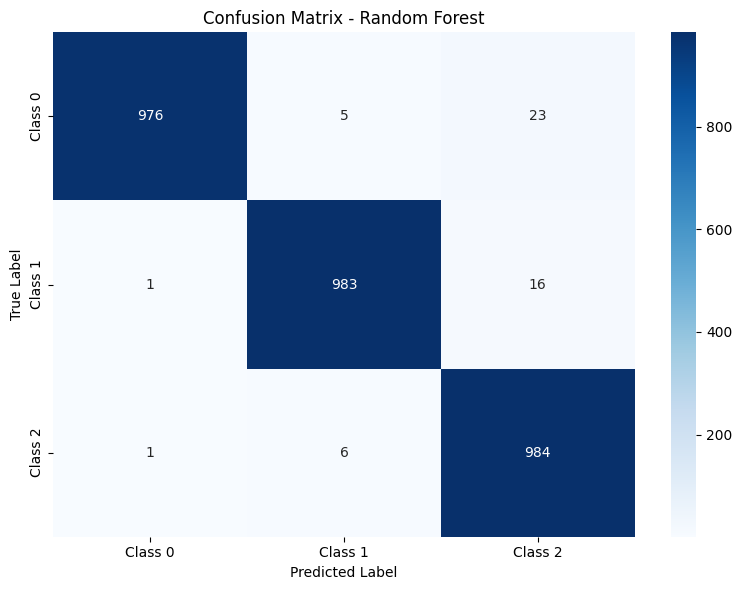

In [174]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Class 0', 'Class 1', 'Class 2'],
            yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig("Confusion-Matrix-RF.png")
plt.show()

In [154]:
import pickle
pickle.dump(rf_grid.best_estimator_, open('exoplanet_classifier.pkl', 'wb'))
print("Model saved!")

Model saved!
